In [1]:
import lropt
import cvxpy as cp

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import numpy.random as npr
import numpy.testing as npt
import scipy as sc
import torch
from sklearn.model_selection import train_test_split

In [3]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 30 # number of time periods
theta = 0.05

In [63]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    d_hat = np.array([1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+1)]) # nominal demand
    d_train_temp = d_hat * np.random.uniform(1-theta, 1+theta, (N, n))

    # d_train = []
    # for i, row in enumerate(d_train_temp):
    #     if i%2 == 0:
    #         d_train.append(row[-2:]) # get demand at times t = 2,3 when y = 2
    #     else:
    #         d_train.append(row[:2]) # get demand at times t = 1,2 when y = 1
    # d_train = np.array(d_train)
    
    return d_hat, d_train_temp

In [64]:
d_hat, data = gen_demand_intro(100, seed)
# d_hat = np.array(d_hat[:-1])

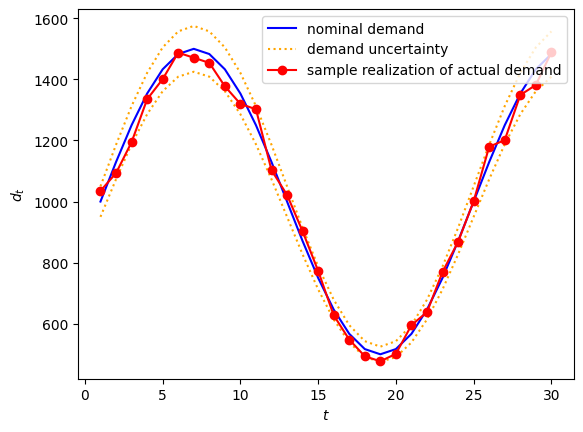

In [65]:
time_periods = np.arange(1,n+1)
plt.plot(time_periods, d_hat, color = "blue", label = "nominal demand")
plt.plot(time_periods, d_hat*(1+theta), linestyle = "dotted", color = "orange", label = "demand uncertainty")
plt.plot(time_periods, d_hat*(1-theta), linestyle = "dotted", color = "orange")
plt.plot(time_periods, data[0], marker = "o", color = "red", label = "sample realization of actual demand")
plt.xlabel("$t$")
plt.ylabel("$d_t$")
plt.legend()

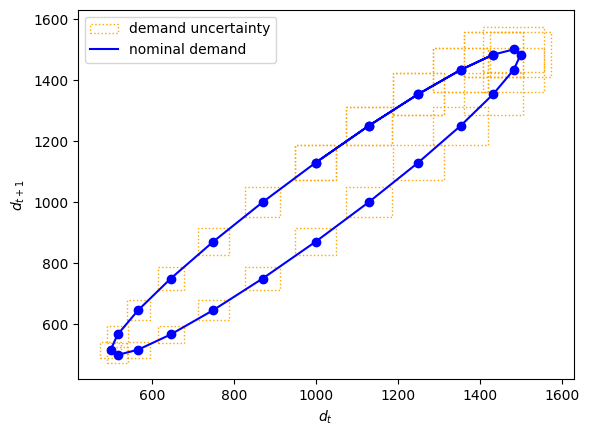

In [66]:
# first point
plt.plot(d_hat[0], d_hat[1], marker = "o", color = "blue")
box_width = 2 * theta * d_hat[0]
box_height = 2 * theta * d_hat[1]
box = Rectangle((d_hat[0] - box_width/2, d_hat[1] - box_height/2), box_width, box_height, 
                linestyle = "dotted", edgecolor='orange', facecolor='none', label = "demand uncertainty")
plt.gca().add_patch(box)

for i in range(1, len(d_hat) - 1):
    plt.plot(d_hat[i], d_hat[i+1], marker = "o", color = "blue")

    # Draw uncertainty box around each point
    box_width = 2 * theta * d_hat[i]
    box_height = 2 * theta * d_hat[i+1]
    box = Rectangle((d_hat[i] - box_width/2, d_hat[i+1] - box_height/2), box_width, box_height, 
                    linestyle = "dotted", edgecolor='orange', facecolor='none')
    plt.gca().add_patch(box)

plt.plot(d_hat[:-1], d_hat[1:], linestyle='-', color='blue', label = "nominal demand")  # Connect points with lines
plt.xlabel("$d_t$")
plt.ylabel("$d_{t+1}$")
plt.legend()

## Training (2 time periods)

In [2]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 2 # 5 # number of time periods

In [3]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    theta = 0.025
    d_hat = [1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, 2*n)] # nominal demand (t = 1, 2, 3)
    d_train_temp = d_hat * np.random.uniform(1-theta, 1+theta, (N, 2*n-1))

    d_train = []
    for i, row in enumerate(d_train_temp):
        d_train.append(row[(i%n):(i%n + 2)]) # get demand time t and t+1
    d_train = np.array(d_train)
    
    return d_hat, d_train

In [4]:
# initialize problem
# cost = np.array([1, 0.87])
cost = [(1 - 0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+1)]
print(cost)
P = np.full(n, 567) # max production capacity at each time period
Q = 1100 # 2700 # max production capacity for all periods
V_min = 500 # minimum inventory
V_max = 2000 # 4000 # maximum inventory
V_1 = 2000 # 4000 # initial inventory
d_hat_all, data = gen_demand_intro(100, seed=15) # demand
d_hat = d_hat_all[:n]
print(d_hat)

[1.0, 0.8705904774487396]
[1000.0, 1129.4095225512604]


In [6]:
# simulating inventories at each time beforehand (no uncertainty in demand)
x = cp.Variable(n)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >=0, x<= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - d_hat @ b >= V_min - V_1)
    constraints.append(x @ b - d_hat @ b <= V_max - V_1)

prob = cp.Problem(objective, constraints)
prob.solve()
opt_obj = prob.value
opt_prod = x.value
x.value

array([ 62.40952283, 566.9999999 ])

In [7]:
inventories = np.zeros(n)
inventories[0] = V_1
for t in range(1, n):
    inventories[t] = inventories[t-1] + opt_prod[t-1] - d_hat[t-1]

y_data = np.array([[t, inventories[t-1]] for t in range(1, n + 1)])
y_data = np.tile(y_data, (int(100/n), 1))

In [12]:
# need to fix this for more than 2 timesteps (cost dimension doesn't match, can only be length of 2)
y = lropt.Parameter(2, data = y_data) 
u = lropt.UncertainParameter(2, uncertainty_set=lropt.Box(data=data))
x = cp.Variable(2)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >= 0, x <= P]

for t in range(n): # for n = 2: one constraint for time t, one constrant for time t and t+1
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    # constraints.append(y @ np.array([0, 1]) + x @ b - u @ b >= V_min)
    # constraints.append(y @ np.array([0, 1]) + x @ b - u @ b <= V_max)
    constraints.append(cp.maximum(y @ np.array([0, 1]) + x @ b - u @ b - V_max, V_min - (y @ np.array([0, 1]) + x @ b - u @ b)) <= 0)

prob = lropt.RobustProblem(objective, constraints)

In [13]:
test_p = 0.1
s = 15
train, _ = train_test_split(data, test_size=int(data.shape[0]*test_p), random_state=s)

initn = sc.linalg.sqrtm(np.cov(train.T))
np.random.seed(15)
init_bvaln = np.mean(train, axis=0)

In [14]:
# Train A and b - constant predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crash

In [15]:
result.df # switch_param_new 1 constraint

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",2880707.913163,427.4716,"[0.5, 0.5]",16921.46264,0.5,"(89.48130389856733,)","([169.71462640452089, 169.71462640452089],)",0.01,"(0.0,)","([0.0, 0.0],)","(tensor(-3054.8601),)","(0.223192626605007,)","([[tensor(0.0903, dtype=torch.float64), tensor..."
1,"(1,)",8584104.657474,427.471228,"[0.5, 0.5]",16887.040912,0.5,"(89.48108811174686,)","([169.71462640452089, 169.71462640452089],)",0.01,"(3.0548603534698486,)","([0.0, 0.0],)","(tensor(-6094.5264),)","(0.22928939509740776,)","([[tensor(0.0950, dtype=torch.float64), tensor..."
2,"(2,)",8529866.395215,427.470547,"[0.5, 0.5]",16806.850471,0.5,"(89.48069327051665,)","([169.71462640452089, 169.71462640452089],)",0.01,"(11.593274116516113,)","([0.0, 0.0],)","(tensor(-6080.0972),)","(0.23521736505492408,)","([[tensor(0.0992, dtype=torch.float64), tensor..."
3,"(3,)",8517595.850627,427.469613,"[0.5, 0.5]",16788.682239,0.5,"(89.48014895308621,)","([169.71462640452089, 169.71462640452089],)",0.01,"(24.50410270690918,)","([0.0, 0.0],)","(tensor(-6076.8311),)","(0.22504051938522615,)","([[tensor(0.0911, dtype=torch.float64), tensor..."
4,"(4,)",8368989.665075,427.468491,"[0.5, 0.5]",16567.868954,0.5,"(89.47949591232447,)","([169.71462640452089, 169.71462640452089],)",0.01,"(40.90959930419922,)","([0.0, 0.0],)","(tensor(-6037.0762),)","(0.2352274035080307,)","([[tensor(0.0999, dtype=torch.float64), tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",1444062.488298,427.298939,"[0.5, 0.5]",1838.700291,0.5,"(89.38103870338702,)","([383.3667729207852, 383.3667729207852],)",0.01001,"(1824.367431640625,)","([0.0, 0.0],)","(tensor(-312.4896),)","(0.22357627909347136,)","([[tensor(0.0897, dtype=torch.float64), tensor..."
96,"(96,)",1445938.462146,427.297041,"[0.5, 0.5]",1841.034849,0.5,"(89.37993766706771,)","([383.3667729207852, 383.3667729207852],)",0.01001,"(1825.5191650390625,)","([0.0, 0.0],)","(tensor(-200.8980),)","(0.23139173943496097,)","([[tensor(0.0971, dtype=torch.float64), tensor..."
97,"(97,)",1446309.308305,427.295138,"[0.5, 0.5]",1841.496335,0.5,"(89.37883229137158,)","([383.3667729207852, 383.3667729207852],)",0.01001,"(1826.6414794921875,)","([0.0, 0.0],)","(tensor(-89.2891),)","(0.2353470456980981,)","([[tensor(0.0993, dtype=torch.float64), tensor..."
98,"(98,)",1448459.496864,427.293224,"[0.5, 0.5]",1844.171942,0.5,"(89.37771946176794,)","([383.3667729207852, 383.3667729207852],)",0.01001,"(1827.628662109375,)","([0.0, 0.0],)","(tensor(22.3238),)","(0.22863282305302546,)","([[tensor(0.0940, dtype=torch.float64), tensor..."


In [11]:
result.df # switch_param_new 2 constraints

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",427.491602,427.4716,"[0.5, 0.0, 0.5, 0.0]",0.01,0.25,"(89.48130389856733,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.2231809615873535,)","([[tensor(0.0903, dtype=torch.float64), tensor..."
1,"(1,)",427.487231,427.471228,"[0.5, 0.0, 0.5, 0.0]",0.008,0.25,"(89.48108814152734,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(0.22684404151655665,)","([[tensor(0.0938, dtype=torch.float64), tensor..."
2,"(2,)",427.47935,427.470551,"[0.5, 0.0, 0.5, 0.0]",0.004399,0.25,"(89.4806957483206,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(0.23585518171706438,)","([[tensor(0.1004, dtype=torch.float64), tensor..."
3,"(3,)",427.468652,427.469618,"[0.5, 0.0, 0.5, 0.0]",-0.000483,0.25,"(89.48015257516855,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.22904468970761763,)","([[tensor(0.0946, dtype=torch.float64), tensor..."
4,"(4,)",427.455713,427.468491,"[0.5, 0.0, 0.5, 0.0]",-0.006388,0.25,"(89.47949611833295,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(0.22345574932954407,)","([[tensor(0.0908, dtype=torch.float64), tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",425.528464,427.298525,"[0.5, 0.0, 0.5, 0.0]",-0.892856,0.25,"(89.38075536069884,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(0.22834526227137272,)","([[tensor(0.0942, dtype=torch.float64), tensor..."
96,"(96,)",425.507244,427.296615,"[0.5, 0.0, 0.5, 0.0]",-0.902686,0.25,"(89.3796449682869,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(0.2219625556535813,)","([[tensor(0.0887, dtype=torch.float64), tensor..."
97,"(97,)",425.486041,427.294716,"[0.5, 0.0, 0.5, 0.0]",-0.912515,0.25,"(89.37854238146618,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(0.22306579949462985,)","([[tensor(0.0897, dtype=torch.float64), tensor..."
98,"(98,)",425.464854,427.292824,"[0.5, 0.0, 0.5, 0.0]",-0.922342,0.25,"(89.37744481470111,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(0.22241657361098932,)","([[tensor(0.0892, dtype=torch.float64), tensor..."


In [12]:
# Train A and b - constant predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor = "CONSTANT",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:848: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robus

In [13]:
result.df # newest version

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",3301399.941583,427.4716,"[0.5, 0.5]",18118.647363,0.5,"(848.8941849635315,)","([181.68647362923616, 181.68647362923616],)",0.01,"(0.0,)","([0.0, 0.0],)","(tensor(-3270.3552),)","(0.035276017302980106,)","([[tensor([0.0022, 0.0022], dtype=torch.float6..."
1,"(1,)",9845755.226497,427.4716,"[0.5, 0.5]",18089.214164,0.5,"(848.8941849635315,)","([181.68647362923616, 181.68647362923616],)",0.01,"(3.270355463027954,)","([0.0, 0.0],)","(tensor(-6526.4204),)","(0.035276017302922284,)","([[tensor([2.1216e-09, 1.6501e-09], dtype=torc..."
2,"(2,)",9786153.841474,427.4716,"[0.5, 0.5]",18006.929813,0.5,"(848.8941849635315,)","([181.68647362923616, 181.68647362923616],)",0.01,"(12.413061141967773,)","([0.0, 0.0],)","(tensor(-6511.6016),)","(0.035276017302949214,)","([[tensor([0.0022, 0.0022], dtype=torch.float6..."
3,"(3,)",9696280.765279,427.4716,"[0.5, 0.5]",17882.497922,0.5,"(848.8941849635315,)","([181.68647362923616, 181.68647362923616],)",0.01,"(26.238826751708984,)","([0.0, 0.0],)","(tensor(-6489.2124),)","(0.03527601730295155,)","([[tensor([6.3996e-09, 5.9317e-09], dtype=torc..."
4,"(4,)",9582645.817989,427.4716,"[0.5, 0.5]",17724.549508,0.5,"(848.8941849635315,)","([181.68647362923616, 181.68647362923616],)",0.01,"(43.78865051269531,)","([0.0, 0.0],)","(tensor(-6460.7778),)","(0.03527601730291895,)","([[tensor([0.0022, 0.0022], dtype=torch.float6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",1553667.508178,427.4716,"[0.5, 0.5]",1851.932504,0.5,"(848.8941849635315,)","([410.0876239150523, 410.0876239150523],)",0.01001,"(1840.7781982421875,)","([0.0, 0.0],)","(tensor(95.2500),)","(0.03527601730290291,)","([[tensor([-6.0735e-15, -1.6087e-14], dtype=to..."
96,"(96,)",1553775.503077,427.4716,"[0.5, 0.5]",1852.058482,0.5,"(848.8941849635315,)","([410.0876239150523, 410.0876239150523],)",0.01001,"(1838.79541015625,)","([0.0, 0.0],)","(tensor(-95.2504),)","(0.03527601730290361,)","([[tensor([0.0022, 0.0022], dtype=torch.float6..."
97,"(97,)",1553917.518512,427.4716,"[0.5, 0.5]",1852.224145,0.5,"(848.8941849635315,)","([410.0876239150523, 410.0876239150523],)",0.01001,"(1837.304443359375,)","([0.0, 0.0],)","(tensor(-95.2508),)","(0.03527601730290361,)","([[tensor([2.4471e-09, 1.8898e-09], dtype=torc..."
98,"(98,)",1554022.059617,427.4716,"[0.5, 0.5]",1852.346093,0.5,"(848.8941849635315,)","([410.0876239150523, 410.0876239150523],)",0.01001,"(1836.2069091796875,)","([0.0, 0.0],)","(tensor(-95.2510),)","(0.03527601730290361,)","([[tensor([-6.0735e-15, -1.6087e-14], dtype=to..."


In [326]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",427.491602,427.4716,"[0.5, 0.0, 0.5, 0.0]",0.01,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.03371873591137354,)","([[tensor([0.0021, 0.0021], dtype=torch.float6..."
1,"(1,)",427.487604,427.4716,"[0.5, 0.0, 0.5, 0.0]",0.008,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(0.03371873591137354,)","([[tensor([-6.0605e-15, -1.6074e-14], dtype=to..."
2,"(2,)",427.4804,427.4716,"[0.5, 0.0, 0.5, 0.0]",0.004399,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(0.03371873591137354,)","([[tensor([0.0021, 0.0021], dtype=torch.float6..."
3,"(3,)",427.470635,427.4716,"[0.5, 0.0, 0.5, 0.0]",-0.000483,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.033718735911373546,)","([[tensor([-6.0605e-15, -1.6074e-14], dtype=to..."
4,"(4,)",427.458822,427.4716,"[0.5, 0.0, 0.5, 0.0]",-0.006388,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(0.03371873591137354,)","([[tensor([0.0021, 0.0021], dtype=torch.float6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",425.70154,427.4716,"[0.5, 0.0, 0.5, 0.0]",-0.892856,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(0.03371873591137354,)","([[tensor([-6.0605e-15, -1.6074e-14], dtype=to..."
96,"(96,)",425.682229,427.4716,"[0.5, 0.0, 0.5, 0.0]",-0.902686,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(0.033718735911373546,)","([[tensor([0.0021, 0.0021], dtype=torch.float6..."
97,"(97,)",425.662926,427.4716,"[0.5, 0.0, 0.5, 0.0]",-0.912515,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(0.03371873591137354,)","([[tensor([-6.0605e-15, -1.6074e-14], dtype=to..."
98,"(98,)",425.643631,427.4716,"[0.5, 0.0, 0.5, 0.0]",-0.922342,0.25,"(848.8941849635315,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(0.033718735911373546,)","([[tensor([-6.0605e-15, -1.6074e-14], dtype=to..."


In [327]:
A_iters, b_iters = result.uncset_iters # A and b at each iteration
print(A_iters[-1][0])
print(b_iters[-1][0])

[[55.71916595 35.36099064]
 [35.36099064 49.00488726]]
[1063.70492654 1189.16743959]


In [328]:
A_fin, b_fin = result.weights
A_fin = A_fin.numpy()
b_fin = b_fin.numpy()
print(A_fin, b_fin)

[[55.71916595 35.36099064]
 [35.36099064 49.00488726]] [1063.70492654 1189.16743959]


In [329]:
## CHECK THIS


num_p = 50
offset = 2
x_min, x_max = np.min(train[:,0]) - offset, np.max(train[:,0]) + offset
y_min, y_max = np.min(train[:,1]) - offset, np.max(train[:,1]) + offset
X = np.linspace(x_min,x_max,num_p)
Y = np.linspace(y_min,y_max,num_p)
x,y = np.meshgrid(X,Y)

fin_set = np.zeros((num_p,num_p))
for i in range(num_p):
    for j in range(num_p):
        u_vec = [x[i,j], y[i,j]]
        fin_set[i,j] = np.linalg.norm((A_fin.T@np.linalg.inv(A_fin@A_fin.T))@(u_vec - b_fin)) # np.linalg.norm((1/eps_list[inds_reshaped[ind]])*(A_fin.T@np.linalg.inv(A_fin@A_fin.T))@(u_vec - b_fin))

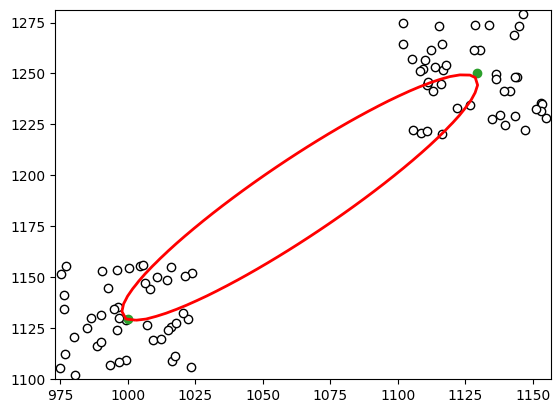

In [330]:
plt.scatter(train[:,0], train[:,1], color = "white",edgecolor = "black")
plt.scatter(d_hat_all[0], d_hat_all[1], color = ["tab:green"])
plt.scatter(d_hat_all[1], d_hat_all[2], color = ["tab:green"])

# box uncertainty set
# box_width = 2 * theta * d_hat_all[0]
# box_height = 2 * theta * d_hat_all[1]
# box = Rectangle((d_hat_all[0] - box_width/2, d_hat_all[1] - box_height/2), box_width, box_height, 
#                 linestyle = "dotted", edgecolor='blue', facecolor='none')
# plt.gca().add_patch(box)

# plot reshaped uncertainty set
plt.contour(x, y, fin_set, [1], colors = ["red"],linewidths = [2])

In [317]:
# Train A and b - linear predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor = "LINEAR",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:848: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
run 0: test value N/A, violations N/A:   0%|            | 0/1

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [183]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",0.020002,-0.0,"[0.5, 0.0, 1.0, 0.0]",0.01,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(1.530519908445782e-15,)","([[tensor([-9.7928e-17, -1.1749e-16], dtype=to..."
1,"(1,)",0.016004,-0.0,"[0.5, 0.0, 1.0, 0.0]",0.008,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(1.530519908445782e-15,)","([[tensor([-3.4951e-17, -3.8514e-17], dtype=to..."
2,"(2,)",0.008799,-0.0,"[0.5, 0.0, 1.0, 0.0]",0.004399,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(1.530519908445782e-15,)","([[tensor([-9.7928e-17, -1.1749e-16], dtype=to..."
3,"(3,)",-0.000966,-0.0,"[0.5, 0.0, 1.0, 0.0]",-0.000483,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(1.530519908445782e-15,)","([[tensor([-3.4951e-17, -3.8514e-17], dtype=to..."
4,"(4,)",-0.012779,-0.0,"[0.5, 0.0, 1.0, 0.0]",-0.006388,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(1.530519908445782e-15,)","([[tensor([-9.7928e-17, -1.1749e-16], dtype=to..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",-1.770061,-0.0,"[0.5, 0.0, 1.0, 0.0]",-0.892856,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(1.530519908445782e-15,)","([[tensor([-3.4951e-17, -3.8514e-17], dtype=to..."
96,"(96,)",-1.789372,-0.0,"[0.5, 0.0, 1.0, 0.0]",-0.902686,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(1.5305199084457822e-15,)","([[tensor([-9.7928e-17, -1.1749e-16], dtype=to..."
97,"(97,)",-1.808675,-0.0,"[0.5, 0.0, 1.0, 0.0]",-0.912515,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(1.530519908445782e-15,)","([[tensor([-3.4951e-17, -3.8514e-17], dtype=to..."
98,"(98,)",-1.82797,-0.0,"[0.5, 0.0, 1.0, 0.0]",-0.922342,0.375,"(1299378.9977718312,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(1.5305199084457822e-15,)","([[tensor([-3.4951e-17, -3.8514e-17], dtype=to..."


In [198]:
w_a, intcpt_a, w_b, intcpt_b = result.weights
w_a = w_a.numpy()
intcpt_a = intcpt_a.numpy()
w_b = w_b.numpy()
intcpt_b = intcpt_b.numpy()
print(w_a, intcpt_a)
print(w_b, intcpt_b)

[[55.71916595 35.36099064]
 [35.36099064 49.00488726]
 [55.71916595 35.36099064]
 [35.36099064 49.00488726]] [-1.08858365 -0.2665963   0.18942346 -0.21902281]
[[1063.70492654 1063.70492654]
 [1189.16743959 1189.16743959]] [1.09925053 2.75653831]


In [220]:
# do this for all the different y's
A_fin1 = (w_a @ y_data[0]) + intcpt_a
A_fin1 = A_fin1.reshape(2, 2)
print(A_fin1)

A_fin2 = (w_a @ y_data[1]) + intcpt_a
A_fin2 = A_fin2.reshape(2, 2)
print(A_fin2)

[[70776.61185678 98044.86891055]
 [70777.88986389 98044.91648405]]
[[37678.20293793 52133.71427315]
 [37679.48094504 52133.76184665]]


In [224]:
# do the same thing for b
b_fin1 = (w_b @ y_data[0]) + intcpt_b
print(b_fin1)

b_fin2 = (w_b @ y_data[1]) + intcpt_b
print(b_fin2)

[2128474.65724794 2379526.80316001]
[1132218.75253511 1265763.90347737]


In [236]:
num_p = 50
offset = 2
x_min, x_max = np.min(train[:,0]) - offset, np.max(train[:,0]) + offset
y_min, y_max = np.min(train[:,1]) - offset, np.max(train[:,1]) + offset
X = np.linspace(x_min,x_max,num_p)
Y = np.linspace(y_min,y_max,num_p)
x,y = np.meshgrid(X,Y)

fin_set = np.zeros((num_p,num_p))
for i in range(num_p):
    for j in range(num_p):
        u_vec = [x[i,j], y[i,j]]
        fin_set[i,j] = np.linalg.norm((A_fin1.T@np.linalg.inv(A_fin1@A_fin1.T))@(u_vec - b_fin1))

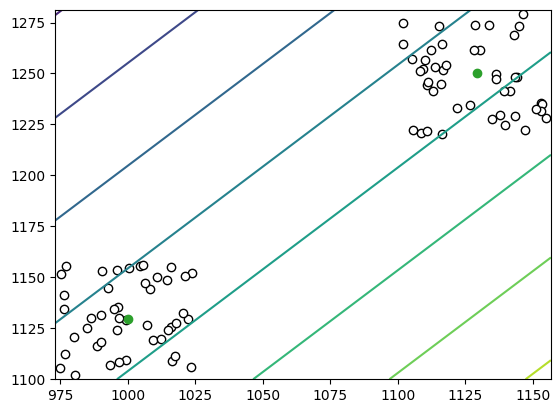

In [245]:
plt.scatter(train[:,0], train[:,1], color = "white",edgecolor = "black")
plt.scatter(d_hat_all[0], d_hat_all[1], color = ["tab:green"])
plt.scatter(d_hat_all[1], d_hat_all[2], color = ["tab:green"])

# box uncertainty set
# box_width = 2 * theta * d_hat_all[0]
# box_height = 2 * theta * d_hat_all[1]
# box = Rectangle((d_hat_all[0] - box_width/2, d_hat_all[1] - box_height/2), box_width, box_height, 
#                 linestyle = "dotted", edgecolor='blue', facecolor='none')
# plt.gca().add_patch(box)

# plot reshaped uncertainty set
plt.contour(x, y, fin_set) # , [1], colors = ["red"],linewidths = [2])

In [ ]:
# k is the information lag
def aarc(k):
    I = 1
    pi_0 = cp.Variable((I, n))
    phi = cp.Variable((I, n*n))
    
    obj = pi_0 @ cost
    constraints = []
    c1 = cp.sum(pi_0, axis = 1)
    c2 = []
    for t in range(n):
        A = np.zeros((n, n))
        if (t - k >= 0):
            A[:t-k, :t-k] = np.identity(t - k)
            
        obj += (1 + theta) * (dist[t] * phi[:, n*t:n*(t+1)] @ A @ d_hat)
        c1 += (1 + theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat)
        constraints.append(pi_0[:, t] + (1 + theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat) <= P[t])
        constraints.append(pi_0[:, t] + (1 - theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat) >= 0)
        c2.append(np.ones(I) @ phi[:, n*t:n*(t+1)] @ A @ d_hat)
    
    objective = cp.Minimize(obj)
    constraints.append(c1 <= Q)
    
    for t in range(n):
        b = np.concatenate((np.ones(t + 1), np.zeros(n - t - 1)))
        constraints.append((np.ones(I) @ pi_0) @ b - (1 - theta) * (b.T @ d_hat) + (1 - theta) * (c2 @ b) <= V_max - v_1)
        constraints.append((np.ones(I) @ pi_0) @ b - (1 + theta) * (b.T @ d_hat) + (1 + theta) * (c2 @ b) >= V_min - v_1)
        
    prob = cp.Problem(objective, constraints)
    print(prob.solve())

In [175]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 2 # number of time periods

In [176]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    theta = 0.025
    d_hat = [1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+2)] # nominal demand (t = 1, 2, 3)
    d_train_temp = d_hat * np.random.uniform(1-theta, 1+theta, (N, n+1))

    d_train = []
    for i, row in enumerate(d_train_temp):
        if i%2 != 0:
            d_train.append(row[-2:]) # get demand at times t = 2,3 when y = 2
        else:
            d_train.append(row[:2]) # get demand at times t = 1,2 when y = 1
    d_train = np.array(d_train)
    
    return d_hat, d_train

In [177]:
# initialize problem
cost = np.array([1, 0.87])
P = np.full(n, 567) # max production capacity at each time period
Q = 1100 # max production capacity for all periods
V_min = 500 # minimum inventory
V_max = 2000 # maximum inventory
V_1 = 2000 # initial inventory
d_hat_all, data = gen_demand_intro(100, seed=15) # demand
d_hat = d_hat_all[:2]
print(d_hat)

[1000.0, 1129.4095225512604]


In [178]:
# simulating inventories at each time beforehand (no uncertainty in demand)
x = cp.Variable(n)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >=0, x<= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - d_hat @ b >= V_min - V_1)
    constraints.append(x @ b - d_hat @ b <= V_max - V_1)

prob = cp.Problem(objective, constraints)
prob.solve()
opt_obj = prob.value
opt_prod = x.value
x.value

array([ 62.40952283, 566.9999999 ])

In [179]:
inventories = np.zeros(n)
inventories[0] = V_1
for t in range(1, n):
    inventories[t] = inventories[t-1] + opt_prod[t-1] - d_hat[t-1]

y_data = np.array([[t, inventories[t-1]] for t in range(1, n + 1)])
y_data = np.tile(y_data, (50, 1))

In [180]:
y = lropt.Parameter(n, data = y_data) 
u = lropt.UncertainParameter(n, uncertainty_set=lropt.Box(data=data))
x = cp.Variable(n)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >= 0, x <= P]

for t in range(n): # for n = 2: one constraint for time t, one constrant for time t and t+1
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(y @ np.array([0, 1]) + x @ b - u @ b >= V_min)
    constraints.append(y @ np.array([0, 1]) + x @ b - u @ b <= V_max)

prob = lropt.RobustProblem(objective, constraints)